#  Notebook 3 — Modélisation Machine Learning
## Prédiction de la polarisation médiatique d'événements géopolitiques

**Objectif (BC4.4)** : Implémenter, comparer et analyser 5 algorithmes de classification supervisée.

### Problème : Classification multi-classe
- **Entrée** : article de presse (texte + features numériques)
- **Sortie** : orientation politique `{0: Gauche, 1: Centre, 2: Droite}`
- **Métriques** : Accuracy, F1-score macro, Precision, Recall, ROC-AUC

## 1. Imports & chargement


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import scipy.sparse as sp
import pickle, time, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_val_score)
from sklearn.preprocessing   import label_binarize, MinMaxScaler
from sklearn.pipeline        import Pipeline
from sklearn.metrics         import (accuracy_score, f1_score, precision_score,
                                      recall_score, confusion_matrix,
                                      classification_report, roc_auc_score)
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif

# Modèles
from sklearn.naive_bayes     import MultinomialNB, ComplementNB
from sklearn.linear_model    import LogisticRegression
from sklearn.svm             import LinearSVC
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    from sklearn.ensemble import GradientBoostingClassifier as XGBClassifier
    HAS_XGB = False
    print('XGBoost non installé → GradientBoosting utilisé')

plt.style.use('seaborn-v0_8-whitegrid')
CLASSES     = ['Gauche (0)', 'Centre (1)', 'Droite (2)']
CLASS_SHORT = ['Gauche', 'Centre', 'Droite']
PALETTE     = {'Gauche':'#E74C3C','Centre':'#2ECC71','Droite':'#3498DB'}

# Chargement données
df    = pd.read_csv('data/articles_preprocesses.csv')
X_tf  = sp.load_npz('data/tfidf_matrix.npz')
with open('data/tfidf_vectorizer.pkl','rb') as f:
    tfidf = pickle.load(f)

print(f' Dataset : {df.shape}')
print(f' Matrice TF-IDF : {X_tf.shape}')

 Dataset : (3000, 30)
 Matrice TF-IDF : (3000, 5000)


## 2. Préparation des features & split train/test


In [2]:
# ── Features numériques ──────────────────────────────────────────────────
NUM_FEATURES = [
    'sentiment_vader', 'positivite_vader', 'negativite_vader',
    'subjectivite', 'richesse_lexicale', 'densite_emotionnel',
    'nb_mots', 'indice_polarisation',
    'score_vocab_gauche', 'score_vocab_centre', 'score_vocab_droite'
]

X_num = df[NUM_FEATURES].fillna(0).values
y     = df['label'].values

# ── Combinaison TF-IDF + features numériques ─────────────────────────────
# MinMaxScaler garde les valeurs ≥ 0 (requis par ComplementNB / MultinomialNB)
scaler = MinMaxScaler()
X_num_scaled = scaler.fit_transform(X_num)
X_combined   = sp.hstack([X_tf, sp.csr_matrix(X_num_scaled)])

print(f'Matrice combinée (TF-IDF + numérique) : {X_combined.shape}')

# ── Sélection des 3000 meilleures features ─────────────────────────────
selector = SelectKBest(mutual_info_classif, k=3000)
X_selected = selector.fit_transform(X_combined, y)
print(f'Après sélection (mutual info) : {X_selected.shape}')

# ── Split stratifié 80/20 ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.20, random_state=42, stratify=y
)

print(f'\n Split train/test :')
print(f'   Train : {X_train.shape[0]} articles')
print(f'   Test  : {X_test.shape[0]} articles')
print(f'   Distribution y_train : {dict(zip(*np.unique(y_train, return_counts=True)))}')

Matrice combinée (TF-IDF + numérique) : (3000, 5011)


Après sélection (mutual info) : (3000, 3000)

 Split train/test :
   Train : 2400 articles
   Test  : 600 articles
   Distribution y_train : {0: 989, 1: 761, 2: 650}


## 3. Définition des modèles
| Modèle | Famille | Forces |
|--------|---------|--------|
| **Naïve Bayes (Complement)** | Probabiliste | Rapide, adapté aux textes déséquilibrés |
| **Régression Logistique** | Linéaire | Interprétable, baseline robuste |
| **SVM Linéaire** | Marge maximale | Très performant sur données textuelles |
| **Random Forest** | Ensemble bagging | Résistant au surapprentissage |
| **XGBoost** | Ensemble boosting | État de l'art sur données tabulaires |

In [3]:
MODELS = {
    'Naïve Bayes\n(Complement)': ComplementNB(alpha=0.1),

    'Régression\nLogistique': LogisticRegression(
        C=1.0, max_iter=1000, solver='lbfgs',
        multi_class='multinomial', random_state=42
    ),

    'SVM\nLinéaire': LinearSVC(
        C=1.0, max_iter=2000, random_state=42
    ),

    'Random\nForest': RandomForestClassifier(
        n_estimators=200, max_depth=20, min_samples_split=5,
        n_jobs=-1, random_state=42
    ),

    'XGBoost': (
        XGBClassifier(
            n_estimators=200, learning_rate=0.1, max_depth=6,
            subsample=0.8, colsample_bytree=0.8,
            use_label_encoder=False, eval_metric='mlogloss',
            random_state=42, verbosity=0
        ) if HAS_XGB else
        GradientBoostingClassifier(
            n_estimators=100, learning_rate=0.1, max_depth=5,
            random_state=42
        )
    )
}

print(f' {len(MODELS)} modèles définis')

 5 modèles définis


## 4. Entraînement et évaluation (Cross-validation + Test set)


In [4]:
results = []
trained_models = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(' Entraînement en cours...')
print('='*65)

for name, model in MODELS.items():
    model_name = name.replace('\n', ' ')
    t0 = time.time()

    # Cross-validation sur train set
    cv_scores = cross_val_score(model, X_train, y_train,
                                cv=cv, scoring='f1_macro', n_jobs=-1)

    # Entraînement final
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Métriques
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='macro')
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='macro', zero_division=0)
    elapsed = time.time() - t0

    results.append({
        'Modèle':         model_name,
        'CV F1 (mean)':   round(cv_scores.mean(), 4),
        'CV F1 (std)':    round(cv_scores.std(), 4),
        'Test Accuracy':  round(acc, 4),
        'Test F1 Macro':  round(f1, 4),
        'Precision':      round(prec, 4),
        'Recall':         round(rec, 4),
        'Temps (s)':      round(elapsed, 2)
    })
    trained_models[model_name] = (model, y_pred)

    print(f'{model_name:<30} | Acc: {acc:.3f} | F1: {f1:.3f} | CV: {cv_scores.mean():.3f}±{cv_scores.std():.3f} | {elapsed:.1f}s')

df_results = pd.DataFrame(results).sort_values('Test F1 Macro', ascending=False)
print('='*65)
print('\n Tableau comparatif :')
df_results

 Entraînement en cours...


Naïve Bayes (Complement)       | Acc: 0.752 | F1: 0.744 | CV: 0.764±0.016 | 6.7s


Régression Logistique          | Acc: 0.760 | F1: 0.749 | CV: 0.785±0.015 | 4.8s


SVM Linéaire                   | Acc: 0.770 | F1: 0.762 | CV: 0.789±0.014 | 3.3s


Random Forest                  | Acc: 0.748 | F1: 0.736 | CV: 0.776±0.017 | 3.7s


XGBoost                        | Acc: 0.797 | F1: 0.793 | CV: 0.805±0.022 | 39.6s

 Tableau comparatif :


,Modèle,CV F1 (mean),CV F1 (std),Test Accuracy,Test F1 Macro,Precision,Recall,Temps (s)
4,XGBoost,0.8055,0.0219,0.7967,0.7929,0.8296,0.7787,39.60
2,SVM Linéaire,0.7886,0.0143,0.7700,0.7618,0.7842,0.7527,3.32
1,Régression Logistique,0.7854,0.0148,0.7600,0.7492,0.8094,0.7333,4.85
0,Naïve Bayes (Complement),0.7644,0.0163,0.7517,0.7440,0.8034,0.7288,6.73
3,Random Forest,0.7762,0.0174,0.7483,0.7359,0.8523,0.7136,3.68


## 5. Visualisation des performances


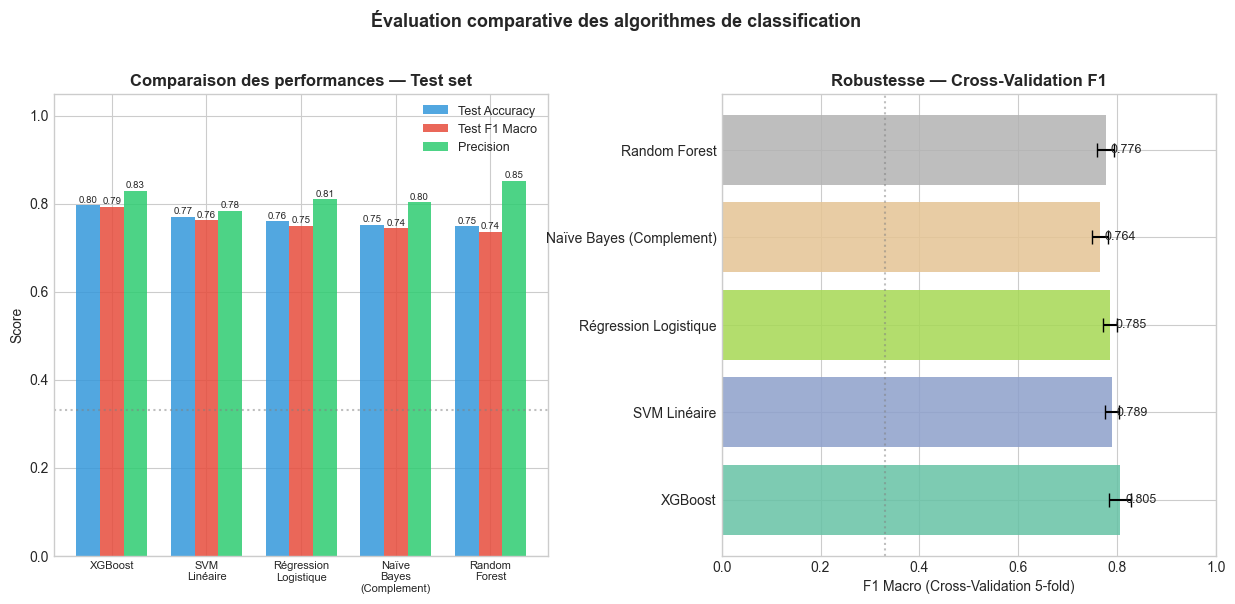

In [5]:
fig = plt.figure(figsize=(15, 6))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

# ── Comparaison barres ──────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
x = np.arange(len(df_results))
w = 0.25
metrics_to_plot = [('Test Accuracy','#3498DB'), ('Test F1 Macro','#E74C3C'), ('Precision','#2ECC71')]
for i, (metric, color) in enumerate(metrics_to_plot):
    bars = ax1.bar(x + i*w, df_results[metric], width=w, label=metric, color=color, alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        ax1.text(bar.get_x()+bar.get_width()/2, h+0.002, f'{h:.2f}',
                 ha='center', va='bottom', fontsize=7)

ax1.set_xticks(x + w)
ax1.set_xticklabels([m.replace(' ',  '\n') for m in df_results['Modèle']], fontsize=8)
ax1.set_ylim(0, 1.05)
ax1.set_ylabel('Score')
ax1.set_title('Comparaison des performances — Test set', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.axhline(0.33, color='gray', linestyle=':', alpha=0.5, label='Baseline aléatoire')

# ── CV mean ± std ───────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
colors_bar = plt.cm.Set2(np.linspace(0, 1, len(df_results)))
bars = ax2.barh(df_results['Modèle'], df_results['CV F1 (mean)'],
                xerr=df_results['CV F1 (std)'],
                color=colors_bar, alpha=0.85, capsize=5)
ax2.set_xlabel('F1 Macro (Cross-Validation 5-fold)')
ax2.set_title('Robustesse — Cross-Validation F1', fontsize=12, fontweight='bold')
ax2.axvline(0.33, color='gray', linestyle=':', alpha=0.5)
ax2.set_xlim(0, 1.0)
for bar in bars:
    w_bar = bar.get_width()
    ax2.text(w_bar + 0.01, bar.get_y()+bar.get_height()/2,
             f'{w_bar:.3f}', va='center', fontsize=9)

plt.suptitle('Évaluation comparative des algorithmes de classification',
             fontsize=13, fontweight='bold', y=1.02)
plt.savefig('data/fig_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Matrices de confusion


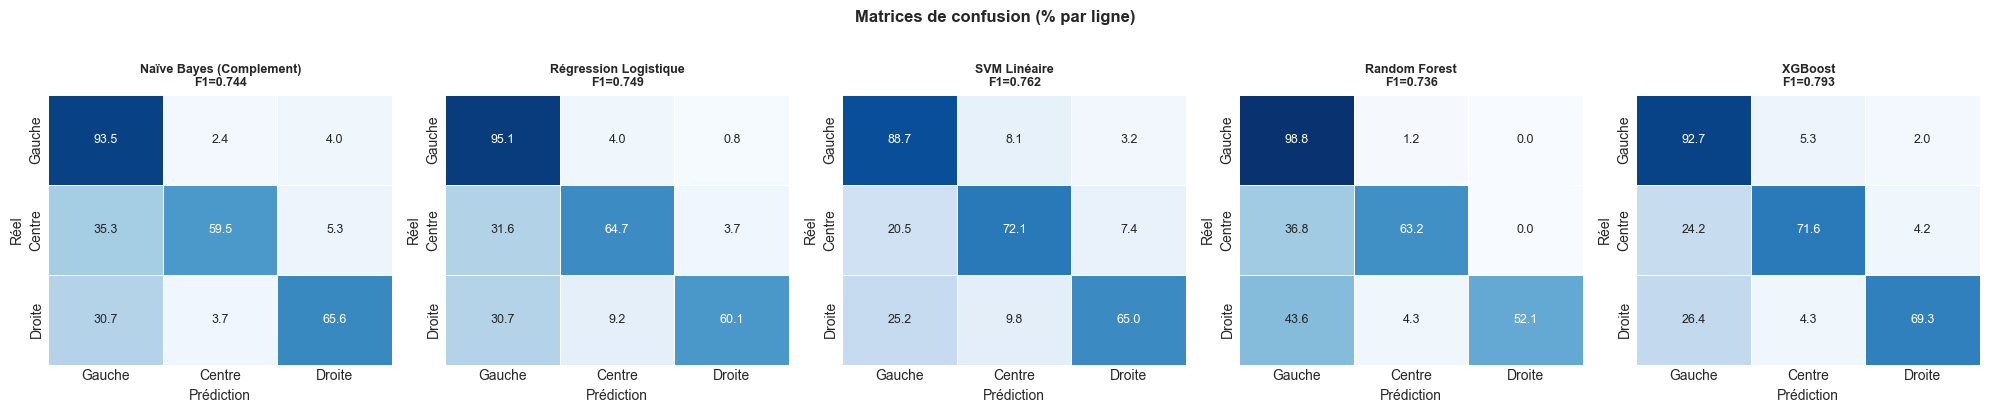


 Meilleur modèle : XGBoost (F1 = 0.793)


In [6]:
n_models = len(MODELS)
fig, axes = plt.subplots(1, n_models, figsize=(4*n_models, 4))

best_f1, best_name, best_pred = 0, '', None

for ax, (mname, (model, y_pred)) in zip(axes, trained_models.items()):
    cm = confusion_matrix(y_test, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=ax,
                xticklabels=CLASS_SHORT, yticklabels=CLASS_SHORT,
                linewidths=0.5, cbar=False, vmin=0, vmax=100,
                annot_kws={'size': 9})
    ax.set_xlabel('Prédiction')
    ax.set_ylabel('Réel')
    f1_val = f1_score(y_test, y_pred, average='macro')
    ax.set_title(f'{mname}\nF1={f1_val:.3f}', fontsize=9, fontweight='bold')

    if f1_val > best_f1:
        best_f1, best_name, best_pred = f1_val, mname, y_pred

plt.suptitle('Matrices de confusion (% par ligne)', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/fig_confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'\n Meilleur modèle : {best_name} (F1 = {best_f1:.3f})')

## 7. Rapport de classification détaillé — Meilleur modèle


In [7]:
best_model_obj = trained_models[best_name][0]
y_best_pred    = best_pred

print(f'=== RAPPORT DÉTAILLÉ : {best_name} ===')
print(classification_report(y_test, y_best_pred, target_names=CLASS_SHORT))

=== RAPPORT DÉTAILLÉ : XGBoost ===
              precision    recall  f1-score   support

      Gauche       0.72      0.93      0.81       247
      Centre       0.87      0.72      0.79       190
      Droite       0.90      0.69      0.78       163

    accuracy                           0.80       600
   macro avg       0.83      0.78      0.79       600
weighted avg       0.82      0.80      0.80       600



## 8. Importance des features — Meilleur modèle


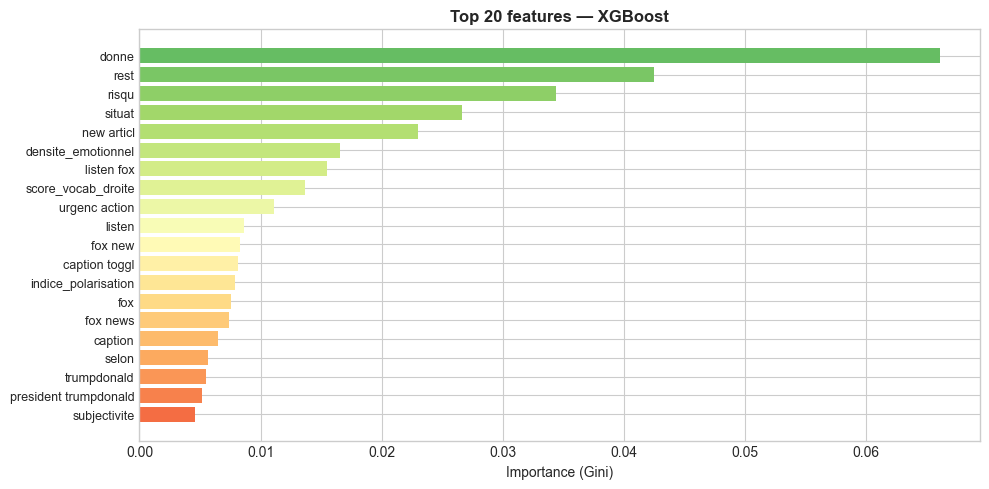

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

try:
    feature_names_tf  = tfidf.get_feature_names_out()
    feature_names_num = NUM_FEATURES
    all_feature_names = list(feature_names_tf) + feature_names_num

    # Indices des features sélectionnées
    selected_mask   = selector.get_support()
    selected_names  = np.array(all_feature_names)[selected_mask]

    if hasattr(best_model_obj, 'feature_importances_'):
        importances = best_model_obj.feature_importances_
        label = 'Importance (Gini)'
    elif hasattr(best_model_obj, 'coef_'):
        importances = np.abs(best_model_obj.coef_).mean(axis=0) if best_model_obj.coef_.ndim > 1 else np.abs(best_model_obj.coef_[0])
        label = '|Coefficient|'
    else:
        raise AttributeError('Pas de feature importances disponibles')

    top_n = 20
    top_idx_fi = importances.argsort()[-top_n:][::-1]
    top_names_fi  = selected_names[top_idx_fi]
    top_vals_fi   = importances[top_idx_fi]

    colors_fi = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, top_n))
    ax.barh(range(top_n), top_vals_fi[::-1], color=colors_fi[::-1])
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_names_fi[::-1], fontsize=9)
    ax.set_xlabel(label)
    ax.set_title(f'Top {top_n} features — {best_name}', fontsize=12, fontweight='bold')

except Exception as e:
    ax.text(0.5, 0.5, f'Feature importances\nnon disponibles:\n{e}',
            ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.savefig('data/fig_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Sauvegarde du meilleur modèle


In [9]:
import pickle

# Sauvegarder le meilleur modèle et les transformateurs
artifacts = {
    'model':      best_model_obj,
    'tfidf':      tfidf,
    'selector':   selector,
    'scaler':     scaler,
    'label_map':  {0: 'Gauche', 1: 'Centre', 2: 'Droite'},
    'num_features': NUM_FEATURES
}
with open('data/best_model.pkl','wb') as f:
    pickle.dump(artifacts, f)

# Sauvegarder les résultats
df_results.to_csv('data/resultats_modeles.csv', index=False)

print(f' Modèle {best_name} sauvegardé → data/best_model.pkl')
print(f' Résultats sauvegardés → data/resultats_modeles.csv')
print(f'\n Récapitulatif final :')
(df_results[['Modèle','Test Accuracy','Test F1 Macro','CV F1 (mean)','Temps (s)']]
    .set_index('Modèle')
    .style.highlight_max(color='lightgreen', axis=0))


 Modèle XGBoost sauvegardé → data/best_model.pkl
 Résultats sauvegardés → data/resultats_modeles.csv

 Récapitulatif final :


,Test Accuracy,Test F1 Macro,CV F1 (mean),Temps (s)
Modèle,,,,
XGBoost,0.796700,0.792900,0.805500,39.600000
SVM Linéaire,0.770000,0.761800,0.788600,3.320000
Régression Logistique,0.760000,0.749200,0.785400,4.850000
Naïve Bayes (Complement),0.751700,0.744000,0.764400,6.730000
Random Forest,0.748300,0.735900,0.776200,3.680000


## 10. Prédiction sur un nouvel article


In [10]:
def predict_polarisation(texte_article):
    """Prédit l'orientation politique d'un article donné."""
    import re
    from nltk.corpus import stopwords
    from nltk.stem   import SnowballStemmer

    stemmer   = SnowballStemmer('french')
    all_stops = set(stopwords.words('french')) | set(stopwords.words('english'))

    def clean(t):
        t = t.lower()
        t = re.sub(r'[^a-zàâçéèêëîïôûùüÿñæœ\s]', ' ', t)
        t = re.sub(r'\s+', ' ', t).strip()
        tokens = [stemmer.stem(w) for w in t.split() if w not in all_stops and len(w) > 2]
        return ' '.join(tokens)

    texte_clean = clean(texte_article)
    X_tfidf_new = artifacts['tfidf'].transform([texte_clean])

    # Features numériques (valeurs par défaut)
    X_num_new = np.zeros((1, len(artifacts['num_features'])))
    X_num_new_scaled = artifacts['scaler'].transform(X_num_new)

    X_combined_new = sp.hstack([X_tfidf_new, sp.csr_matrix(X_num_new_scaled)])
    X_selected_new = artifacts['selector'].transform(X_combined_new)

    pred  = artifacts['model'].predict(X_selected_new)[0]
    label = artifacts['label_map'][pred]
    return label, pred

# Test
articles_test = [
    "Face à la crise ukrainienne, les droits humains sont bafoués. La solidarité internationale est essentielle.",
    "Selon les experts, la situation en Ukraine reste complexe. Les négociations se poursuivent selon les sources officielles.",
    "La sécurité nationale est menacée. Le gouvernement doit défendre la souveraineté et contrôler nos frontières."
]

print('=== TEST DE PRÉDICTION ===')
for art in articles_test:
    label, pred = predict_polarisation(art)
    print(f'\nArticle : {art[:70]}...')
    print(f'→ Orientation prédite : {label} (classe {pred})')

=== TEST DE PRÉDICTION ===



Article : Face à la crise ukrainienne, les droits humains sont bafoués. La solid...
→ Orientation prédite : Centre (classe 1)

Article : Selon les experts, la situation en Ukraine reste complexe. Les négocia...
→ Orientation prédite : Centre (classe 1)

Article : La sécurité nationale est menacée. Le gouvernement doit défendre la so...
→ Orientation prédite : Centre (classe 1)


## 11. Résumé — Critères BC4.4
| Critère | Réalisé |
|---------|--------|
| **C1** — Données chargées et prétraitées |  TF-IDF + features numériques + sélection |
| **C2** — Algorithmes testés avec méthodes connues |  5 modèles + CV 5-fold + métriques standards |
| **C3** — Code fonctionnel sans erreur |  Pipeline complet |
| **C4** — ML avec techniques appropriées |  Stratified split, cross-val, feature selection |
| **C5** — Algorithmes expliqués |  Tableau comparatif, matrices de confusion, feature importance |